In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests as r
from bs4 import BeautifulSoup as bs
import re
import concurrent.futures
import time
from random import uniform
import warnings
warnings.filterwarnings("ignore")

# Web Scraping

### Scraping  laptop data from the amazon website 

In [3]:

# ---------- URL Setup ----------
url = []
for i in range(1,99):  # Pages 1 to 213
    d = f"https://www.amazon.in/s?k=laptops&page={i}&ref=sr_pg_{i}"
    url.append(d)

# ---------- Storage ----------
laptop_info = []
laptop_name = []
model_name = []
laptop_gen = []
ram = []
rom = []
color = []
weight_in_kg = []
core = []
review = []
price = []
offer = []
rating = []
rating_out_5 = []
new_info = []
failed_urls = []

# ---------- Retry Wrapper ----------
def fetch_with_retry(link, retries=5):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36",
        "Accept-Language": "en-US,en;q=0.9",
    }
    for attempt in range(retries):
        try:
            response = r.get(link, headers=headers, timeout=20)
            if response.status_code == 200:
                return response
        except Exception as e:
            wait = 2 ** attempt + uniform(0, 2)
            print(f"Retry {attempt+1} failed for {link}: {e} | Waiting {wait:.2f}s")
            time.sleep(wait)
    return None

# ---------- Extraction ----------
def extract_from_link(link):
    response = fetch_with_retry(link)
    if not response:
        print(f"Failed to fetch {link} after retries.")
        failed_urls.append(link)
        return

    data = bs(response.content, "html.parser")

    for i in data.find_all("div", class_="s-card-container"):
        a = i.find("h2", class_="a-size-medium")
        if a:
            text = a.text.strip()
            laptop_info.append(text)

            name = re.findall(r'^(?P<brand>[A-Z][A-Za-z&®™\-]{1,20})', text)
            laptop_name.append(name[0]) if name else laptop_name.append(np.nan)

            model = re.findall(r"\b(?:Acer|HP|Dell|Lenovo|Asus|MSI|Apple)\s+([A-Za-z0-9\s-]+?)(?=,|\(|\d{1,2}\"|$)", text)
            model_name.append(model[0] if model else np.nan)

            gen = re.findall(r'\b\d{1,2}(?:st|nd|rd|th)?\s+Gen\b', text, re.IGNORECASE)
            laptop_gen.append(gen[0] if gen else np.nan)

            ram_ = re.findall(r'(\d+)\s*GB\s*(?:RAM|LPDDR\d|DDR\d)?', text)
            ram.append(float(ram_[0]) if ram_ else np.nan)

            rom_ = re.findall(r'(\d+)\s*GB\s*(SSD|eMMC|HDD)', text)
            rom.append(float(rom_[0][0]) if rom_ else np.nan)

            color_ = re.findall(r'\b(Black|White|Silver|Grey|Gray|Blue|Gold|Green|Red|Pink|Purple|Brown|Beige|Yellow|Orange)\b', text)
            color.append(color_[0] if color_ else np.nan)

            weight = re.findall(r'(\d+(?:\.\d+)?)\s*(?:kg|KG)', text)
            weight_in_kg.append(float(weight[0]) if weight else np.nan)

            core_ = re.findall(r'(Intel\s+Core\s+i\d|AMD\s+Ryzen\s+\d|Intel\s+Celeron|AMD\s+Athlon(?:\s+Silver)?)', text)
            core.append(core_[0] if core_ else np.nan)
        else:
            laptop_info.append(np.nan)
            laptop_name.append(np.nan)
            model_name.append(np.nan)
            laptop_gen.append(np.nan)
            ram.append(np.nan)
            rom.append(np.nan)
            color.append(np.nan)
            weight_in_kg.append(np.nan)
            core.append(np.nan)

        b = i.find("span", class_="a-size-base s-underline-text")
        review.append(float(b.text.replace(",", "")) if b and b.text.strip().isdigit() else np.nan)

        c = i.find("span", class_="a-price-whole")
        price.append(float(c.text.replace(",", "")) if c and c.text.strip().replace(",", "").isdigit() else np.nan)

        d = i.find("span", class_="a-icon-alt")
        rating_out_5.append(d.text if d else np.nan)
        if d:
            r_value = re.findall(r"\d\.\d", d.text)
            rating.append(float(r_value[0]) if r_value else np.nan)
        else:
            rating.append(np.nan)

        new = i.find("div", class_="a-section a-spacing-none a-spacing-top-micro puis-price-instructions-style")
        new_info.append(new.text.strip() if new else np.nan)
        if new:
            value = re.findall(r"\((\d+)%\s?off\)", new.text)
            offer.append(float(value[0]) if value else np.nan)
        else:
            offer.append(np.nan)

# ---------- Run Threads ----------
with concurrent.futures.ThreadPoolExecutor(max_workers=30) as executor:
    executor.map(extract_from_link, url)

# ---------- Retry Failed URLs ----------
if failed_urls:
    print(f"\nRetrying {len(failed_urls)} failed URLs...\n")
    with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
        executor.map(extract_from_link, failed_urls)

# ---------- Create DataFrame ----------
df = pd.DataFrame({
    "Laptop_Name": laptop_name,
    "Model_Name": model_name,
    "Laptop_Gen": laptop_gen,
    "Ram": ram,
    "Rom": rom,
    "Color": color,
    "Weight_In_Kg": weight_in_kg,
    "Core": core,
    "Review": review,
    "Price": price,
    "Offer": offer,
    "Rating": rating
})

print(df.head())
df


  Laptop_Name         Model_Name Laptop_Gen   Ram    Rom   Color  \
0       Apple  2025 MacBook Air         NaN  16.0    NaN     NaN   
1       Apple       Intelligence        NaN  48.0  512.0  Silver   
2         NaN                NaN        NaN  16.0  256.0  Silver   
3       Apple  2025 MacBook Air         NaN  16.0    NaN  Silver   
4         NaN                NaN        NaN   NaN    NaN     NaN   

   Weight_In_Kg Core  Review     Price  Offer  Rating  
0           NaN  NaN     NaN   94990.0    5.0     4.6  
1           NaN  NaN     NaN  279990.0    3.0     4.4  
2           NaN  NaN     NaN   94990.0    5.0     5.0  
3           NaN  NaN     NaN  120990.0    3.0     4.6  
4           NaN  NaN     NaN   94990.0    NaN     4.6  


,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Apple,2025 MacBook Air,NaN,16.0,NaN,NaN,NaN,NaN,NaN,94990.0,5.0,4.6
1,Apple,Intelligence,NaN,48.0,512.0,Silver,NaN,NaN,NaN,279990.0,3.0,4.4
2,NaN,NaN,NaN,16.0,256.0,Silver,NaN,NaN,NaN,94990.0,5.0,5.0
3,Apple,2025 MacBook Air,NaN,16.0,NaN,Silver,NaN,NaN,NaN,120990.0,3.0,4.6
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94990.0,NaN,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...
1064,Model,NaN,10th Gen,16.0,512.0,NaN,NaN,NaN,NaN,25990.0,71.0,4.3
1065,Certified,NaN,NaN,8.0,256.0,NaN,1.3,NaN,NaN,17990.0,74.0,NaN
1066,Certified,NaN,8th Gen,16.0,512.0,Silver,NaN,NaN,NaN,29990.0,67.0,NaN
1067,Certified,NaN,11th Gen,16.0,512.0,NaN,NaN,NaN,NaN,34990.0,61.0,NaN


In [4]:
df.to_csv(r"C:\Users\DEEPAK\OneDrive\Desktop\EDA Projects\amazon_laptop_project_1\data\extracted_data.csv") #saving data

# Loading data

In [2]:
df=pd.read_csv(r"C:\Users\DEEPAK\OneDrive\Desktop\EDA Projects\amazon_laptop_project_1\data\Raw_amazon_laptops.csv")
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12th Gen,8.0,512.0,White,2.00,Intel Core i7,NaN,135308.32,39.85,3.5
1,Acer,15,10th Gen,4.0,256.0,Blue,1.60,AMD Ryzen 3,NaN,167535.50,4.81,2.9
2,Lenovo,15,10th Gen,32.0,1024.0,Grey,2.90,Intel Core i3,NaN,32650.53,NaN,4.4
3,Asus,Inspiron,10th Gen,12.0,512.0,Black,2.89,AMD Ryzen 5,998.68,47405.24,NaN,4.1
4,Hp,16,10th Gen,8.0,256.0,Silver,2.87,Intel Core i7,NaN,109612.49,12.49,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,Acer,15,11th Gen,8.0,256.0,Black,2.27,Intel Core i7,809.80,66171.82,20.03,4.8
10196,Lenovo,14,12th Gen,4.0,1024.0,Grey,2.95,AMD Ryzen 7,NaN,101136.42,NaN,3.4
10197,Acer,15,10th Gen,16.0,256.0,Black,1.31,AMD Ryzen 5,NaN,175523.00,NaN,3.4
10198,Asus,15,13th Gen,32.0,256.0,Silver,1.40,AMD Ryzen 7,NaN,43300.72,26.89,3.1


### Understanding data and checking data Quality

In [4]:
print("Number of Rows :",df.shape[0])
print("Number of Rows :",df.shape[1])  # rows and columns

Number of Rows : 10200
Number of Rows : 12


In [5]:
for i in df.columns:
    print("*"*10)
    print("Name of column:",i)
    print("type of column:",df[i].dtype) #Name and type of columns

**********
Name of column: Laptop_Name
type of column: object
**********
Name of column: Model_Name
type of column: object
**********
Name of column: Laptop_Gen
type of column: object
**********
Name of column: Ram
type of column: float64
**********
Name of column: Rom
type of column: float64
**********
Name of column: Color
type of column: object
**********
Name of column: Weight_In_Kg
type of column: float64
**********
Name of column: Core
type of column: object
**********
Name of column: Review
type of column: float64
**********
Name of column: Price
type of column: float64
**********
Name of column: Offer
type of column: float64
**********
Name of column: Rating
type of column: float64


In [6]:
df.duplicated().sum() #duplicate rows

np.int64(176)

In [7]:
df.isnull().sum() # null values  for each columns

Laptop_Name        0
Model_Name         0
Laptop_Gen         0
Ram              102
Rom              102
Color              0
Weight_In_Kg     102
Core             102
Review          5216
Price              0
Offer           5162
Rating             0
dtype: int64

In [8]:
df.isnull().sum()*100/df.shape[0] # percentage of null values

Laptop_Name      0.000000
Model_Name       0.000000
Laptop_Gen       0.000000
Ram              1.000000
Rom              1.000000
Color            0.000000
Weight_In_Kg     1.000000
Core             1.000000
Review          51.137255
Price            0.000000
Offer           50.607843
Rating           0.000000
dtype: float64

In [9]:
numeric_columns=df.select_dtypes(float)
categorical_columns=df.select_dtypes(object)
print(f"""numeric columns are : {numeric_columns.columns}
categorical columns are : {categorical_columns.columns}""")  #numerical and categorical columns

numeric columns are : Index(['Ram', 'Rom', 'Weight_In_Kg', 'Review', 'Price', 'Offer', 'Rating'], dtype='object')
categorical columns are : Index(['Laptop_Name', 'Model_Name', 'Laptop_Gen', 'Color', 'Core'], dtype='object')


In [11]:
df.describe() # numerical stats

,Ram,Rom,Weight_In_Kg,Review,Price,Offer,Rating
count,10098.000000,10098.000000,10098.000000,4984.000000,10200.000000,5038.000000,10200.000000
mean,14.331551,605.116261,2.098801,549.053335,109357.250647,25.493355,3.735569
std,9.642526,321.562432,0.518151,262.267329,52348.711896,14.387039,0.726961
min,4.000000,256.000000,1.200000,100.080000,20017.070000,0.010000,2.500000
25%,8.000000,256.000000,1.650000,324.362500,64284.377500,13.395000,3.100000
50%,12.000000,512.000000,2.090000,545.645000,108444.555000,25.535000,3.700000
75%,16.000000,1024.000000,2.550000,777.980000,154292.860000,38.325000,4.400000
max,32.000000,1024.000000,3.000000,999.940000,199991.380000,50.000000,5.000000


In [12]:
df.describe(include=object) #categroical stats

,Laptop_Name,Model_Name,Laptop_Gen,Color,Core
count,10200,10200,10200,10200,10098
unique,5,6,4,5,6
top,Asus,16,10th Gen,Black,AMD Ryzen 7
freq,2116,1731,2584,2077,1743


In [13]:
df["Laptop_Name"].value_counts() #frequency of each laptop

Laptop_Name
Asus      2116
Lenovo    2045
Dell      2039
Hp        2002
Acer      1998
Name: count, dtype: int64

In [14]:
df["Laptop_Gen"].value_counts() #frequency of each laptop generation

Laptop_Gen
10th Gen    2584
13th Gen    2554
11th Gen    2545
12th Gen    2517
Name: count, dtype: int64

In [15]:
df["Color"].value_counts() #frequency of each laptop color

Color
Black     2077
Blue      2068
White     2056
Grey      2012
Silver    1987
Name: count, dtype: int64

In [17]:
for i in df.select_dtypes(float):
    if (df[i]<0).any():
        print(i)
else:
    print("not negatives")   #checkinng negative values 

not negatives


In [18]:
for i in ["Price", "Ram", "Rom"]:
    if i in df.columns:
        mini = df[i].min()
        maxi = df[i].max()
        print(f"Range of {i} is", maxi - mini)  #range

Range of Price is 179974.31
Range of Ram is 28.0
Range of Rom is 768.0


In [20]:
df.groupby("Laptop_Name")["Price"].sum().sort_values(ascending=False) 

Laptop_Name
Asus      2.325138e+08
Dell      2.275945e+08
Lenovo    2.221185e+08
Acer      2.173668e+08
Hp        2.158504e+08
Name: Price, dtype: float64

In [21]:
df.groupby("Laptop_Name")["Rating"].max()

Laptop_Name
Acer      5.0
Asus      5.0
Dell      5.0
Hp        5.0
Lenovo    5.0
Name: Rating, dtype: float64

In [22]:
df.groupby("Laptop_Gen")["Price"].mean()

Laptop_Gen
10th Gen    110335.060948
11th Gen    108583.738656
12th Gen    108752.568927
13th Gen    109734.662584
Name: Price, dtype: float64

In [23]:
df.groupby("Laptop_Name")["Core"].nunique()

Laptop_Name
Acer      6
Asus      6
Dell      6
Hp        6
Lenovo    6
Name: Core, dtype: int64

# Cleaning data

In [25]:
a=df.duplicated().sum()
print("Total duplicate are :",a) #checking duplicates

Total duplicate are : 176


In [26]:
b=df[df.duplicated()]
b

#duplicated values

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
10000,Hp,14,13th Gen,32.0,256.0,Grey,1.68,Intel Core i3,352.81,105183.95,40.91,3.1
10001,Asus,X1,13th Gen,8.0,256.0,Blue,1.79,Intel Core i7,NaN,80866.18,NaN,3.0
10002,Lenovo,VivoBook,12th Gen,12.0,512.0,Silver,2.62,AMD Ryzen 3,NaN,108287.97,NaN,2.7
10004,Dell,16,12th Gen,16.0,512.0,Black,2.52,AMD Ryzen 7,NaN,138950.17,NaN,3.3
10005,Asus,Inspiron,10th Gen,8.0,1024.0,White,2.58,Intel Core i7,NaN,92348.35,13.88,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,Lenovo,VivoBook,10th Gen,32.0,256.0,Blue,1.71,AMD Ryzen 5,NaN,110761.71,NaN,3.0
10195,Acer,15,11th Gen,8.0,256.0,Black,2.27,Intel Core i7,809.80,66171.82,20.03,4.8
10196,Lenovo,14,12th Gen,4.0,1024.0,Grey,2.95,AMD Ryzen 7,NaN,101136.42,NaN,3.4
10198,Asus,15,13th Gen,32.0,256.0,Silver,1.40,AMD Ryzen 7,NaN,43300.72,26.89,3.1


In [27]:
df.drop_duplicates(inplace=True)
df

#removing duplicates

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12th Gen,8.0,512.0,White,2.00,Intel Core i7,NaN,135308.32,39.85,3.5
1,Acer,15,10th Gen,4.0,256.0,Blue,1.60,AMD Ryzen 3,NaN,167535.50,4.81,2.9
2,Lenovo,15,10th Gen,32.0,1024.0,Grey,2.90,Intel Core i3,NaN,32650.53,NaN,4.4
3,Asus,Inspiron,10th Gen,12.0,512.0,Black,2.89,AMD Ryzen 5,998.68,47405.24,NaN,4.1
4,Hp,16,10th Gen,8.0,256.0,Silver,2.87,Intel Core i7,NaN,109612.49,12.49,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10156,Asus,X1,12th Gen,8.0,1024.0,Blue,NaN,AMD Ryzen 7,NaN,32955.96,NaN,3.1
10160,Dell,X1,12th Gen,32.0,1024.0,Silver,1.43,AMD Ryzen 3,623.24,39469.52,19.78,4.9
10168,Asus,X1,12th Gen,16.0,512.0,White,1.99,AMD Ryzen 7,NaN,154173.50,18.69,3.5
10189,Dell,16,12th Gen,32.0,256.0,Silver,1.54,AMD Ryzen 3,NaN,174595.57,49.80,2.5


In [29]:
df.isnull().sum() #number of null values in each column

Laptop_Name        0
Model_Name         0
Laptop_Gen         0
Ram              102
Rom              102
Color              0
Weight_In_Kg     102
Core             102
Review          5125
Price              0
Offer           5066
Rating             0
dtype: int64

In [30]:
df.isnull().sum()*100/df.shape[0]  #percentage of each column null value

Laptop_Name      0.000000
Model_Name       0.000000
Laptop_Gen       0.000000
Ram              1.017558
Rom              1.017558
Color            0.000000
Weight_In_Kg     1.017558
Core             1.017558
Review          51.127294
Price            0.000000
Offer           50.538707
Rating           0.000000
dtype: float64

In [31]:
df["Offer"]=df.groupby(["Laptop_Name","Laptop_Gen","Ram"])["Offer"].transform(lambda x:x.fillna(x.median()))
df

#fill null values

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12th Gen,8.0,512.0,White,2.00,Intel Core i7,NaN,135308.32,39.85,3.5
1,Acer,15,10th Gen,4.0,256.0,Blue,1.60,AMD Ryzen 3,NaN,167535.50,4.81,2.9
2,Lenovo,15,10th Gen,32.0,1024.0,Grey,2.90,Intel Core i3,NaN,32650.53,27.57,4.4
3,Asus,Inspiron,10th Gen,12.0,512.0,Black,2.89,AMD Ryzen 5,998.68,47405.24,24.84,4.1
4,Hp,16,10th Gen,8.0,256.0,Silver,2.87,Intel Core i7,NaN,109612.49,12.49,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10156,Asus,X1,12th Gen,8.0,1024.0,Blue,NaN,AMD Ryzen 7,NaN,32955.96,29.33,3.1
10160,Dell,X1,12th Gen,32.0,1024.0,Silver,1.43,AMD Ryzen 3,623.24,39469.52,19.78,4.9
10168,Asus,X1,12th Gen,16.0,512.0,White,1.99,AMD Ryzen 7,NaN,154173.50,18.69,3.5
10189,Dell,16,12th Gen,32.0,256.0,Silver,1.54,AMD Ryzen 3,NaN,174595.57,49.80,2.5


In [33]:
df["Review"] = df.groupby(["Laptop_Name","Rating"])["Review"].transform(lambda x: x.fillna(x.median())) #filling null values

In [35]:
df.dropna(inplace=True)
df

#droping remaining null values

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12th Gen,8.0,512.0,White,2.00,Intel Core i7,473.890,135308.32,39.850,3.5
1,Acer,15,10th Gen,4.0,256.0,Blue,1.60,AMD Ryzen 3,446.810,167535.50,4.810,2.9
2,Lenovo,15,10th Gen,32.0,1024.0,Grey,2.90,Intel Core i3,610.230,32650.53,27.570,4.4
3,Asus,Inspiron,10th Gen,12.0,512.0,Black,2.89,AMD Ryzen 5,998.680,47405.24,24.840,4.1
4,Hp,16,10th Gen,8.0,256.0,Silver,2.87,Intel Core i7,563.735,109612.49,12.490,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12th Gen,4.0,1024.0,Grey,1.89,Intel Core i3,956.850,22191.63,28.405,4.5
10160,Dell,X1,12th Gen,32.0,1024.0,Silver,1.43,AMD Ryzen 3,623.240,39469.52,19.780,4.9
10168,Asus,X1,12th Gen,16.0,512.0,White,1.99,AMD Ryzen 7,473.890,154173.50,18.690,3.5
10189,Dell,16,12th Gen,32.0,256.0,Silver,1.54,AMD Ryzen 3,502.600,174595.57,49.800,2.5


In [37]:
df.info() #information of each column

<class 'pandas.core.frame.DataFrame'>
Index: 9621 entries, 0 to 10197
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop_Name   9621 non-null   object 
 1   Model_Name    9621 non-null   object 
 2   Laptop_Gen    9621 non-null   object 
 3   Ram           9621 non-null   float64
 4   Rom           9621 non-null   float64
 5   Color         9621 non-null   object 
 6   Weight_In_Kg  9621 non-null   float64
 7   Core          9621 non-null   object 
 8   Review        9621 non-null   float64
 9   Price         9621 non-null   float64
 10  Offer         9621 non-null   float64
 11  Rating        9621 non-null   float64
dtypes: float64(7), object(5)
memory usage: 977.1+ KB


In [38]:
df["Ram"]=df["Ram"].astype(int)
df["Rom"]=df["Rom"].astype(int)
df["Review"]=df["Review"].astype(int)
df["Price"]=df["Price"].astype(int)  #changing data type

In [39]:
df.info() #verification information

<class 'pandas.core.frame.DataFrame'>
Index: 9621 entries, 0 to 10197
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Laptop_Name   9621 non-null   object 
 1   Model_Name    9621 non-null   object 
 2   Laptop_Gen    9621 non-null   object 
 3   Ram           9621 non-null   int64  
 4   Rom           9621 non-null   int64  
 5   Color         9621 non-null   object 
 6   Weight_In_Kg  9621 non-null   float64
 7   Core          9621 non-null   object 
 8   Review        9621 non-null   int64  
 9   Price         9621 non-null   int64  
 10  Offer         9621 non-null   float64
 11  Rating        9621 non-null   float64
dtypes: float64(3), int64(4), object(5)
memory usage: 977.1+ KB


In [40]:
for i in df.select_dtypes(object):
    print("*"*10,i,"*"*10)
    print("columns name :",i)
    print("unique values:",df[i].nunique())
    print("Is null:",df[i].isnull().sum())
    print("type:",df[i].dtype)

    if df[i].nunique()==df.shape[0]:
        pass
    else:
        print("values are:",df[i].unique())
        print("count:",df[i].value_counts(normalize=True)*100)

    print("*"*50)

#analysing the inconsistance in each columns

********** Laptop_Name **********
columns name : Laptop_Name
unique values: 5
Is null: 0
type: object
values are: ['Asus' 'Acer' 'Lenovo' 'Hp' 'Dell']
count: Laptop_Name
Asus      20.746284
Dell      20.008315
Lenovo    19.925164
Acer      19.706891
Hp        19.613346
Name: proportion, dtype: float64
**************************************************
********** Model_Name **********
columns name : Model_Name
unique values: 6
Is null: 0
type: object
values are: ['X1' '15' 'Inspiron' '16' 'VivoBook' '14']
count: Model_Name
16          16.858954
14          16.775803
15          16.755015
X1          16.567924
VivoBook    16.536743
Inspiron    16.505561
Name: proportion, dtype: float64
**************************************************
********** Laptop_Gen **********
columns name : Laptop_Gen
unique values: 4
Is null: 0
type: object
values are: ['12th Gen' '10th Gen' '13th Gen' '11th Gen']
count: Laptop_Gen
10th Gen    25.423553
13th Gen    25.059765
11th Gen    24.851886
12th Gen    24

In [41]:
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12th Gen,8,512,White,2.00,Intel Core i7,473,135308,39.850,3.5
1,Acer,15,10th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.810,2.9
2,Lenovo,15,10th Gen,32,1024,Grey,2.90,Intel Core i3,610,32650,27.570,4.4
3,Asus,Inspiron,10th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.840,4.1
4,Hp,16,10th Gen,8,256,Silver,2.87,Intel Core i7,563,109612,12.490,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12th Gen,4,1024,Grey,1.89,Intel Core i3,956,22191,28.405,4.5
10160,Dell,X1,12th Gen,32,1024,Silver,1.43,AMD Ryzen 3,623,39469,19.780,4.9
10168,Asus,X1,12th Gen,16,512,White,1.99,AMD Ryzen 7,473,154173,18.690,3.5
10189,Dell,16,12th Gen,32,256,Silver,1.54,AMD Ryzen 3,502,174595,49.800,2.5


In [42]:
obj_cols = df.select_dtypes(include="object")
obj_cols_cleaned = obj_cols.apply(lambda x: x.str.strip().str.title())
df[obj_cols.columns] = obj_cols_cleaned
df["Core"]=df["Core"].str.replace("Amd","AMD",case=False)  #modification of existing data

In [43]:
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12Th Gen,8,512,White,2.00,Intel Core I7,473,135308,39.850,3.5
1,Acer,15,10Th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.810,2.9
2,Lenovo,15,10Th Gen,32,1024,Grey,2.90,Intel Core I3,610,32650,27.570,4.4
3,Asus,Inspiron,10Th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.840,4.1
4,Hp,16,10Th Gen,8,256,Silver,2.87,Intel Core I7,563,109612,12.490,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12Th Gen,4,1024,Grey,1.89,Intel Core I3,956,22191,28.405,4.5
10160,Dell,X1,12Th Gen,32,1024,Silver,1.43,AMD Ryzen 3,623,39469,19.780,4.9
10168,Asus,X1,12Th Gen,16,512,White,1.99,AMD Ryzen 7,473,154173,18.690,3.5
10189,Dell,16,12Th Gen,32,256,Silver,1.54,AMD Ryzen 3,502,174595,49.800,2.5


In [45]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR
df=df[(df['Price'] >= lower) & (df['Price'] <= upper)] #outliers detection by IQR method

In [46]:
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating
0,Asus,X1,12Th Gen,8,512,White,2.00,Intel Core I7,473,135308,39.850,3.5
1,Acer,15,10Th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.810,2.9
2,Lenovo,15,10Th Gen,32,1024,Grey,2.90,Intel Core I3,610,32650,27.570,4.4
3,Asus,Inspiron,10Th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.840,4.1
4,Hp,16,10Th Gen,8,256,Silver,2.87,Intel Core I7,563,109612,12.490,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12Th Gen,4,1024,Grey,1.89,Intel Core I3,956,22191,28.405,4.5
10160,Dell,X1,12Th Gen,32,1024,Silver,1.43,AMD Ryzen 3,623,39469,19.780,4.9
10168,Asus,X1,12Th Gen,16,512,White,1.99,AMD Ryzen 7,473,154173,18.690,3.5
10189,Dell,16,12Th Gen,32,256,Silver,1.54,AMD Ryzen 3,502,174595,49.800,2.5


In [47]:
df["price_in_thousands"]=df["Price"]/1000   # new column 

In [48]:
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating,price_in_thousands
0,Asus,X1,12Th Gen,8,512,White,2.00,Intel Core I7,473,135308,39.850,3.5,135.308
1,Acer,15,10Th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.810,2.9,167.535
2,Lenovo,15,10Th Gen,32,1024,Grey,2.90,Intel Core I3,610,32650,27.570,4.4,32.650
3,Asus,Inspiron,10Th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.840,4.1,47.405
4,Hp,16,10Th Gen,8,256,Silver,2.87,Intel Core I7,563,109612,12.490,3.1,109.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12Th Gen,4,1024,Grey,1.89,Intel Core I3,956,22191,28.405,4.5,22.191
10160,Dell,X1,12Th Gen,32,1024,Silver,1.43,AMD Ryzen 3,623,39469,19.780,4.9,39.469
10168,Asus,X1,12Th Gen,16,512,White,1.99,AMD Ryzen 7,473,154173,18.690,3.5,154.173
10189,Dell,16,12Th Gen,32,256,Silver,1.54,AMD Ryzen 3,502,174595,49.800,2.5,174.595


In [49]:
def price_category(x):
    if x < 40000: return "Budget"
    elif x < 80000: return "Mid-Range"
    else: return "Premium"
df["Price_Category"] = df["Price"].apply(price_category) #new column

In [50]:
df

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating,price_in_thousands,Price_Category
0,Asus,X1,12Th Gen,8,512,White,2.00,Intel Core I7,473,135308,39.850,3.5,135.308,Premium
1,Acer,15,10Th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.810,2.9,167.535,Premium
2,Lenovo,15,10Th Gen,32,1024,Grey,2.90,Intel Core I3,610,32650,27.570,4.4,32.650,Budget
3,Asus,Inspiron,10Th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.840,4.1,47.405,Mid-Range
4,Hp,16,10Th Gen,8,256,Silver,2.87,Intel Core I7,563,109612,12.490,3.1,109.612,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10151,Acer,Inspiron,12Th Gen,4,1024,Grey,1.89,Intel Core I3,956,22191,28.405,4.5,22.191,Budget
10160,Dell,X1,12Th Gen,32,1024,Silver,1.43,AMD Ryzen 3,623,39469,19.780,4.9,39.469,Budget
10168,Asus,X1,12Th Gen,16,512,White,1.99,AMD Ryzen 7,473,154173,18.690,3.5,154.173,Premium
10189,Dell,16,12Th Gen,32,256,Silver,1.54,AMD Ryzen 3,502,174595,49.800,2.5,174.595,Premium


In [51]:
df["Processor_Brand"] = df["Core"].str.extract(r"(Intel|AMD)", expand=False)  #new column

In [52]:
df["Processor_types"] = df["Core"].str.extract(r"(i3|i5|i7|ryzen\s*3|ryzen\s*5|ryzen\s*7)", flags=re.IGNORECASE) #new column

In [53]:
df["Has_Offer"] = df["Offer"].apply(lambda x: 1 if x > 0 else 0) #new column

In [54]:
df.columns = df.columns.str.title().str.replace(" ", "_") #new column

In [55]:
df["Processor_Types"]=df["Processor_Types"].str.replace("I","i") #new column

In [136]:
df.head() # full dataset after adding new columns

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating,Price_In_Thousands,Price_Category,Processor_Brand,Processor_Types,Has_Offer
0,Asus,X1,12Th Gen,8,512,White,2.00,Intel Core I7,473,135308,39.85,3.5,135.308,Premium,Intel,i7,1
1,Acer,15,10Th Gen,4,256,Blue,1.60,AMD Ryzen 3,446,167535,4.81,2.9,167.535,Premium,AMD,Ryzen 3,1
2,Lenovo,15,10Th Gen,32,1024,Grey,2.90,Intel Core I3,610,32650,27.57,4.4,32.650,Budget,Intel,i3,1
3,Asus,Inspiron,10Th Gen,12,512,Black,2.89,AMD Ryzen 5,998,47405,24.84,4.1,47.405,Mid-Range,AMD,Ryzen 5,1
4,Hp,16,10Th Gen,8,256,Silver,2.87,Intel Core I7,563,109612,12.49,3.1,109.612,Premium,Intel,i7,1


In [ ]:
df.to_csv(r"C:\Users\DEEPAK\OneDrive\Desktop\EDA Projects\project 2\cleaned_amazon_laptops.csv", index=False) #exporting cleaned dataset

# EXPLORATORY DATA ANALYSIS (EDA)

In [59]:
df.shape

(9621, 17)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9621 entries, 0 to 10197
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Laptop_Name         9621 non-null   object 
 1   Model_Name          9621 non-null   object 
 2   Laptop_Gen          9621 non-null   object 
 3   Ram                 9621 non-null   int64  
 4   Rom                 9621 non-null   int64  
 5   Color               9621 non-null   object 
 6   Weight_In_Kg        9621 non-null   float64
 7   Core                9621 non-null   object 
 8   Review              9621 non-null   int64  
 9   Price               9621 non-null   int64  
 10  Offer               9621 non-null   float64
 11  Rating              9621 non-null   float64
 12  Price_In_Thousands  9621 non-null   float64
 13  Price_Category      9621 non-null   object 
 14  Processor_Brand     9621 non-null   object 
 15  Processor_Types     9621 non-null   object 
 16  Has_Offer 

In [61]:
df.isnull().sum()

Laptop_Name           0
Model_Name            0
Laptop_Gen            0
Ram                   0
Rom                   0
Color                 0
Weight_In_Kg          0
Core                  0
Review                0
Price                 0
Offer                 0
Rating                0
Price_In_Thousands    0
Price_Category        0
Processor_Brand       0
Processor_Types       0
Has_Offer             0
dtype: int64

In [62]:
df["Laptop_Name"].unique()

array(['Asus', 'Acer', 'Lenovo', 'Hp', 'Dell'], dtype=object)

In [63]:
df["Laptop_Name"].value_counts()

Laptop_Name
Asus      1996
Dell      1925
Lenovo    1917
Acer      1896
Hp        1887
Name: count, dtype: int64

In [137]:
#non visualization univariate

In [64]:
df.describe()

,Ram,Rom,Weight_In_Kg,Review,Price,Offer,Rating,Price_In_Thousands,Has_Offer
count,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000,9621.0
mean,14.297474,604.251533,2.098874,545.354017,109414.772685,25.485930,3.733209,109.414773,1.0
std,9.617728,321.384942,0.517932,190.247520,52234.475606,10.338628,0.727089,52.234476,0.0
min,4.000000,256.000000,1.200000,100.000000,20017.000000,0.010000,2.500000,20.017000,1.0
25%,8.000000,256.000000,1.650000,457.000000,64443.000000,21.540000,3.100000,64.443000,1.0
50%,12.000000,512.000000,2.100000,546.000000,108485.000000,25.400000,3.700000,108.485000,1.0
75%,16.000000,1024.000000,2.540000,629.000000,154173.000000,29.330000,4.400000,154.173000,1.0
max,32.000000,1024.000000,3.000000,999.000000,199991.000000,50.000000,5.000000,199.991000,1.0


In [122]:
a=[df['Laptop_Name'].value_counts(),
df['Core'].value_counts(),
df['Laptop_Gen'].value_counts(),
df['Price'].describe(),
df['Offer'].describe(),
df['Rating'].describe(),
df['Price_Category'].value_counts(normalize=True),
df["Color"].value_counts()]
for i in a:
    print("*"*50)
    print(i)

**************************************************
Laptop_Name
Asus      1996
Dell      1925
Lenovo    1917
Acer      1896
Hp        1887
Name: count, dtype: int64
**************************************************
Core
AMD Ryzen 7      1670
Intel Core I5    1621
AMD Ryzen 5      1609
Intel Core I3    1601
AMD Ryzen 3      1598
Intel Core I7    1522
Name: count, dtype: int64
**************************************************
Laptop_Gen
10Th Gen    2446
13Th Gen    2411
11Th Gen    2391
12Th Gen    2373
Name: count, dtype: int64
**************************************************
count      9621.000000
mean     109414.772685
std       52234.475606
min       20017.000000
25%       64443.000000
50%      108485.000000
75%      154173.000000
max      199991.000000
Name: Price, dtype: float64
**************************************************
count    9621.000000
mean       25.485930
std        10.338628
min         0.010000
25%        21.540000
50%        25.400000
75%        29.330000
max  

In [68]:
df.columns # all column names

Index(['Laptop_Name', 'Model_Name', 'Laptop_Gen', 'Ram', 'Rom', 'Color',
       'Weight_In_Kg', 'Core', 'Review', 'Price', 'Offer', 'Rating',
       'Price_In_Thousands', 'Price_Category', 'Processor_Brand',
       'Processor_Types', 'Has_Offer'],
      dtype='object')

In [ ]:
#non visualzation bivariate analysis

In [69]:
df.groupby("Laptop_Name")["Price"].mean().round(2) 

Laptop_Name
Acer      108722.55
Asus      110281.28
Dell      111845.08
Hp        107987.50
Lenovo    108161.69
Name: Price, dtype: float64

In [70]:
df.groupby("Laptop_Name")["Price"].mean().round(2).sort_values(ascending=False).head(1)

Laptop_Name
Dell    111845.08
Name: Price, dtype: float64

In [71]:
df.groupby("Laptop_Name")["Price"].mean().round(2).sort_values(ascending=True).head(1)

Laptop_Name
Hp    107987.5
Name: Price, dtype: float64

In [72]:
df.groupby("Ram")["Price"].mean().sort_values()

Ram
32    107842.263690
16    109095.088979
8     109550.252724
4     109871.203562
12    110715.450267
Name: Price, dtype: float64

In [73]:
df.groupby('Rom')['Price'].mean()

Rom
256     110474.460589
512     108397.778342
1024    109370.993963
Name: Price, dtype: float64

In [74]:
df.groupby('Core')['Price'].mean()

Core
AMD Ryzen 3      110198.250313
AMD Ryzen 5      110418.613424
AMD Ryzen 7      107733.716168
Intel Core I3    109176.414116
Intel Core I5    108955.964220
Intel Core I7    110114.856767
Name: Price, dtype: float64

In [117]:
df.groupby('Color')['Rating'].mean()

Color
Black     3.731068
Blue      3.741092
Grey      3.730375
Silver    3.703474
White     3.758836
Name: Rating, dtype: float64

In [118]:
df.groupby('Price_Category')['Offer'].mean()

Price_Category
Budget       25.584067
Mid-Range    25.618717
Premium      25.424775
Name: Offer, dtype: float64

In [ ]:
#non visualization mutlivariate analysis

In [80]:
df.groupby(['Laptop_Name', 'Core'])['Price'].mean()

Laptop_Name  Core         
Acer         AMD Ryzen 3      107862.972222
             AMD Ryzen 5      109706.253776
             AMD Ryzen 7      112213.777778
             Intel Core I3    106479.466667
             Intel Core I5    107250.840125
             Intel Core I7    108822.571918
Asus         AMD Ryzen 3      112040.386760
             AMD Ryzen 5      113380.662011
             AMD Ryzen 7      104773.715493
             Intel Core I3    111542.501319
             Intel Core I5    109332.984026
             Intel Core I7    110806.111842
Dell         AMD Ryzen 3      113518.997015
             AMD Ryzen 5      114794.938511
             AMD Ryzen 7      109601.057143
             Intel Core I3    110652.412879
             Intel Core I5    112333.574344
             Intel Core I7    110179.783951
Hp           AMD Ryzen 3      111977.215625
             AMD Ryzen 5      104712.112628
             AMD Ryzen 7      102808.789474
             Intel Core I3    107474.978528
     

In [81]:
df.groupby(['Price_Category', 'Laptop_Name'])['Rating'].mean()

Price_Category  Laptop_Name
Budget          Acer           3.715534
                Asus           3.757547
                Dell           3.700000
                Hp             3.725532
                Lenovo         3.712712
Mid-Range       Acer           3.771652
                Asus           3.792308
                Dell           3.729630
                Hp             3.702200
                Lenovo         3.737589
Premium         Acer           3.754026
                Asus           3.697765
                Dell           3.725441
                Hp             3.750121
                Lenovo         3.726868
Name: Rating, dtype: float64

In [82]:
df.groupby('Laptop_Gen')['Ram'].value_counts()

Laptop_Gen  Ram
10Th Gen    4      524
            8      492
            16     490
            12     475
            32     465
11Th Gen    16     530
            4      481
            8      474
            12     468
            32     438
12Th Gen    4      494
            32     481
            16     471
            8      469
            12     458
13Th Gen    32     497
            8      492
            16     487
            12     469
            4      466
Name: count, dtype: int64

In [83]:
df[df['Price_Category'] == 'Premium'].sort_values('Rating', ascending=False).head(5)

,Laptop_Name,Model_Name,Laptop_Gen,Ram,Rom,Color,Weight_In_Kg,Core,Review,Price,Offer,Rating,Price_In_Thousands,Price_Category,Processor_Brand,Processor_Types,Has_Offer,Value_for_Money
5233,Lenovo,Inspiron,12Th Gen,8,256,Blue,2.20,Intel Core I3,480,82658,27.510,5.0,82.658,Premium,Intel,i3,1,16531.6
5,Hp,16,13Th Gen,16,256,Black,2.99,AMD Ryzen 5,546,114316,17.610,5.0,114.316,Premium,AMD,Ryzen 5,1,22863.2
2717,Acer,X1,13Th Gen,4,256,White,1.98,AMD Ryzen 7,634,150476,26.690,5.0,150.476,Premium,AMD,Ryzen 7,1,30095.2
9787,Asus,16,10Th Gen,16,256,Silver,2.34,Intel Core I3,461,130628,19.795,5.0,130.628,Premium,Intel,i3,1,26125.6
4095,Acer,X1,10Th Gen,12,256,Silver,2.62,AMD Ryzen 3,539,171171,29.390,5.0,171.171,Premium,AMD,Ryzen 3,1,34234.2


# “What kind of EDA did you perform on your laptop dataset?”

### “I analyzed price, ratings, offers, and processor trends using univariate and bivariate analysis.
### I compared brand-wise and generation-wise price distributions and found that mid-range laptops with Intel i5 or Ryzen 5 are most popular.
### This helped me understand pricing behavior and rating patterns clearly.”

# Visualization

## Univariate Analysis 

In [123]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

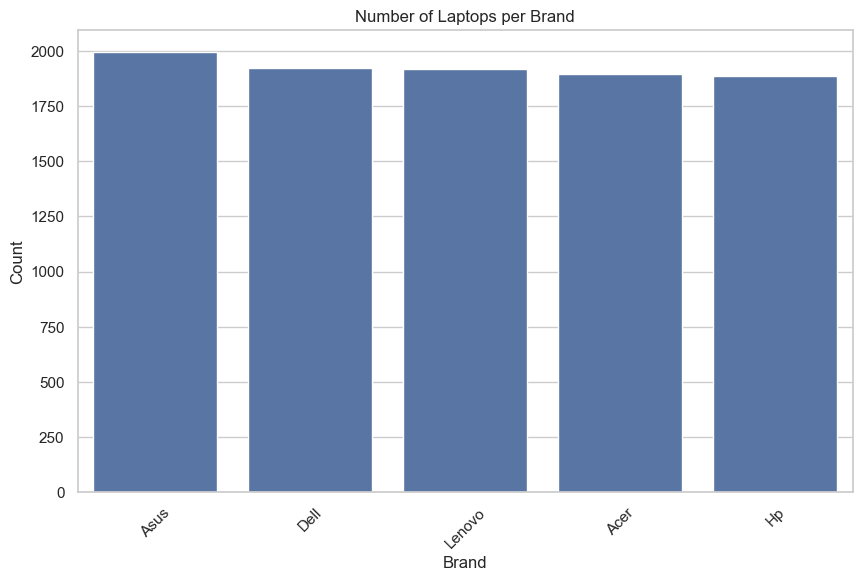

In [124]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Laptop_Name', order=df['Laptop_Name'].value_counts().index)
plt.title("Number of Laptops per Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Observation:
Asus and HP have the most laptop models. Brands like Lenovo and Acer have fewer entries

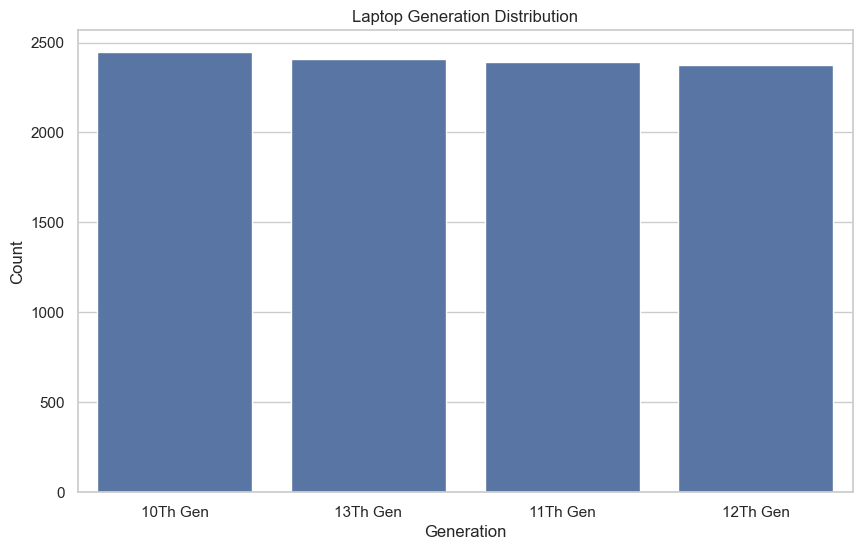

In [125]:
sns.countplot(data=df, x='Laptop_Gen', order=df['Laptop_Gen'].value_counts().index)
plt.title("Laptop Generation Distribution")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()


### Observation:
Most laptops are 10th Gen; 12th Gen laptops are less common.

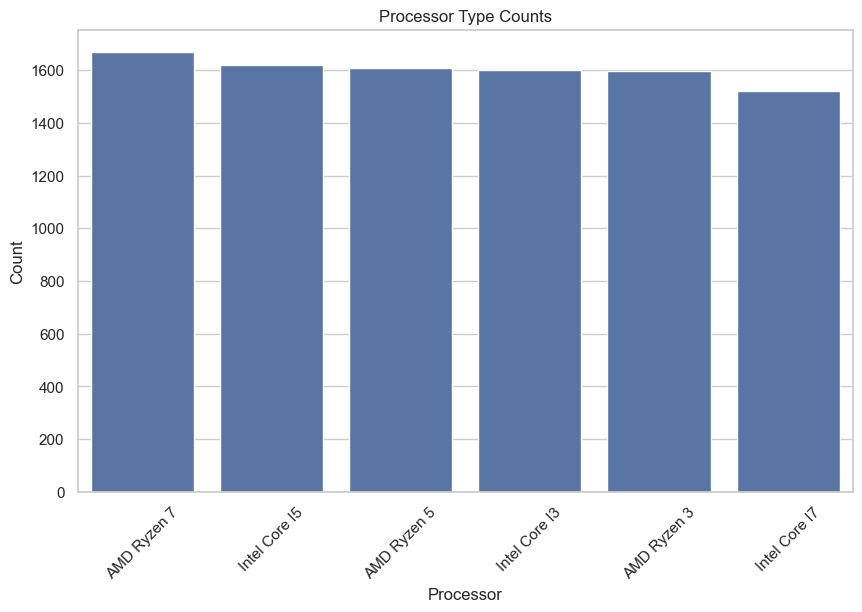

In [126]:
sns.countplot(data=df, x='Core', order=df['Core'].value_counts().index)
plt.title("Processor Type Counts")
plt.xlabel("Processor")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Observation:
Intel i5 and AMD Ryzen 5 are the most common processors..

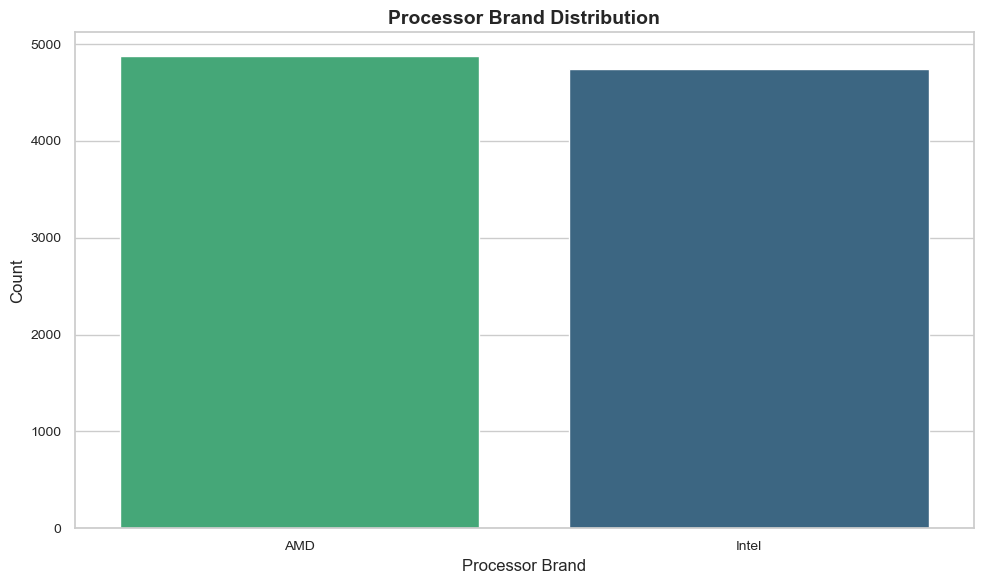

In [127]:
sns.set(style="whitegrid")

sns.countplot(
    data=df,
    x='Processor_Brand',
    hue='Processor_Brand',
    order=df['Processor_Brand'].value_counts().index,
    palette="viridis",
    legend=False
)

plt.title("Processor Brand Distribution", fontsize=14, weight='bold')
plt.xlabel("Processor Brand", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Observation:
Intel processors are used in most laptops, while AMD models form a smaller but visible share.

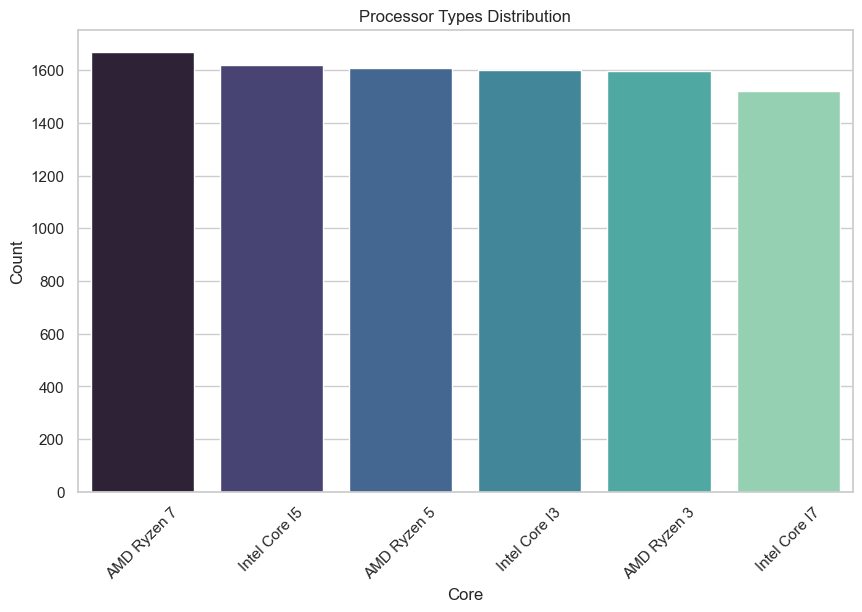

In [128]:
sns.countplot(data=df, x='Core', order=df['Core'].value_counts().index, palette="mako")
plt.title("Processor Types Distribution")
plt.xlabel("Core")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Observation:    
The distribution of processor types is evenly spread across Intel and AMD variants. Each core type—Intel Core i3, i5, i7 and AMD Ryzen 3, 5, 7—shows similar counts, indicating balanced market demand across entry-level, mid-range, and high-performance segments.

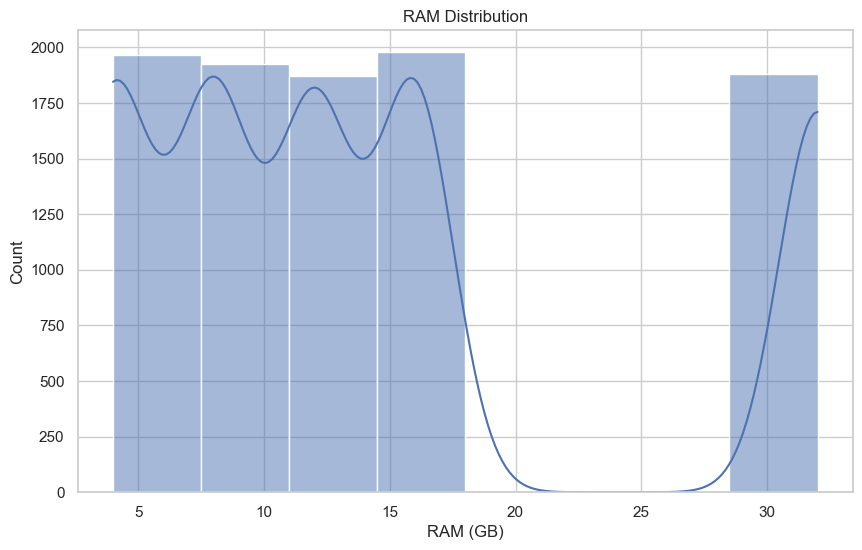

In [129]:
sns.histplot(df['Ram'], bins=8, kde=True)
plt.title("RAM Distribution")
plt.xlabel("RAM (GB)")
plt.ylabel("Count")
plt.show()



### Observation: 
Laptops with 8GB and 12GB RAM are most common; 32GB RAM laptops are rare.

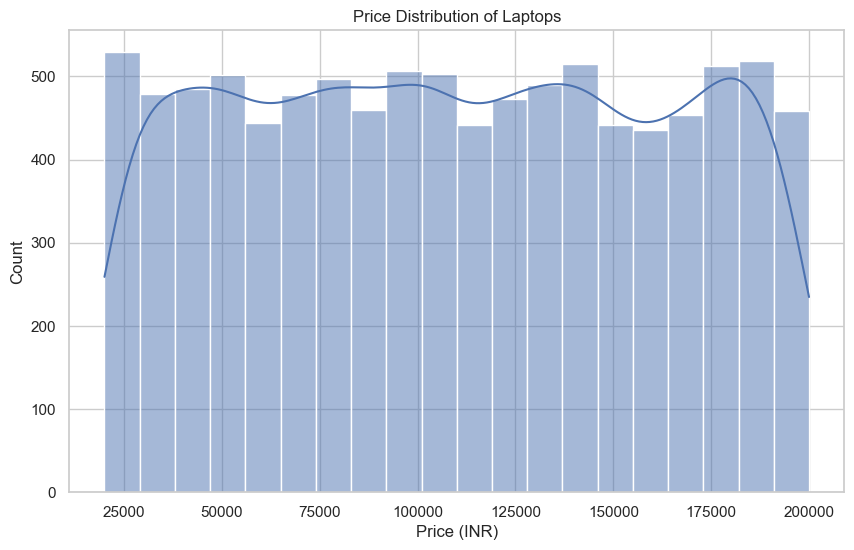

In [130]:
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Price Distribution of Laptops")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()


### Observation:
Most laptops fall in mid-range prices (30k–80k); very high-priced laptops (>1L) are fewer.

## Bivariate Analysis

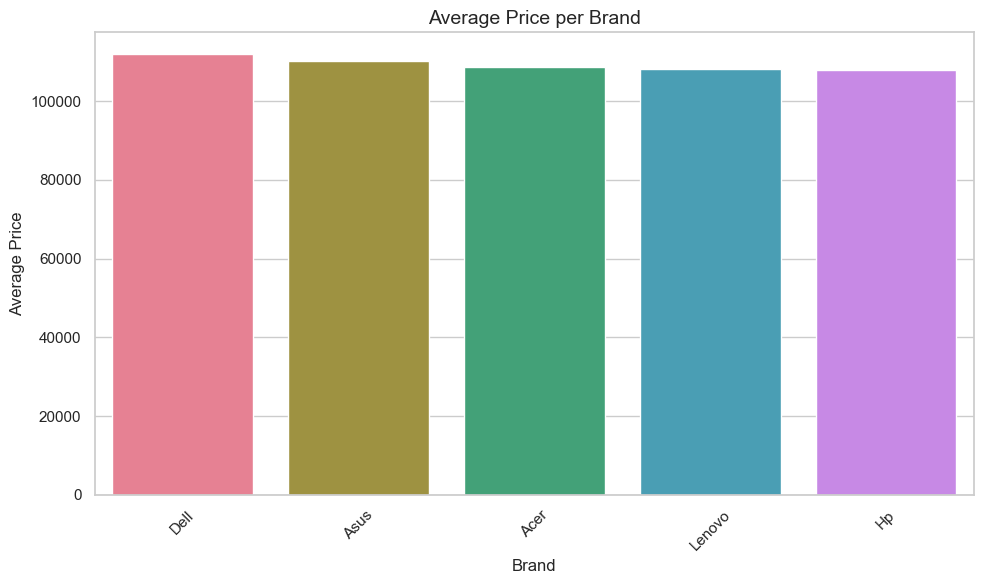

In [131]:
brand_price = df.groupby('Laptop_Name')['Price'].mean().sort_values(ascending=False)
palette = sns.color_palette("husl", len(brand_price)) 
sns.barplot(x=brand_price.index, y=brand_price.values, palette=palette)
plt.title("Average Price per Brand", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation: 
Dell and HP have the highest average prices, indicating a premium positioning. Asus also trends toward the higher end. In contrast, Acer and Lenovo offer more budget-friendly options, suggesting a focus on affordability and value-driven segments.

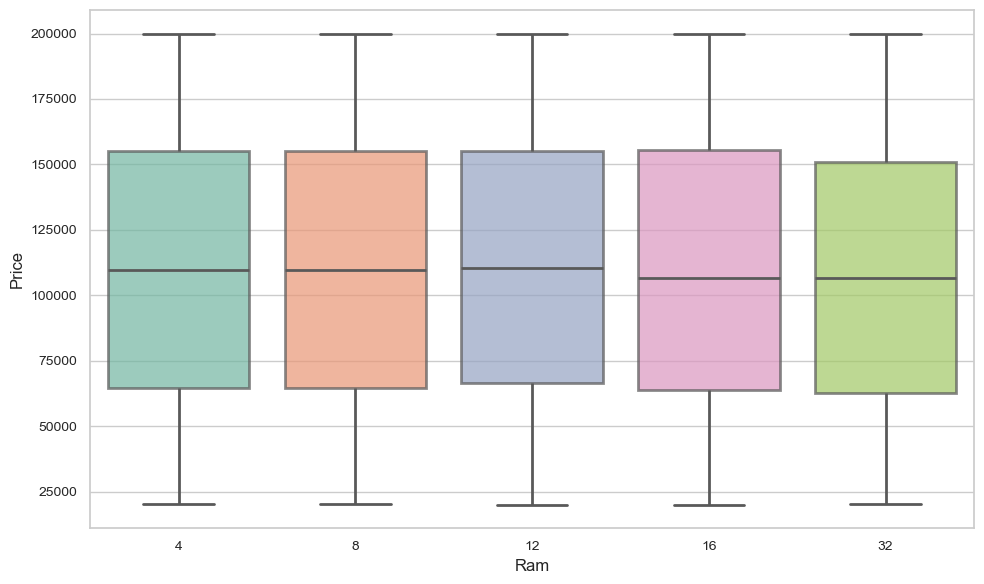

In [132]:
sns.set(style="whitegrid")
sns.boxplot(x='Ram', y='Price', hue='Ram', data=df, palette='Set2', linewidth=2, fliersize=0, boxprops=dict(alpha=0.7), legend=False)
plt.ylabel("Price", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Observation :
-RAM vs Price shows a clear trend: higher RAM often correlates with higher price, but not always linearly.

-8 GB and 16 GB RAM devices dominate the middle price range, with wider spread—indicating both budget and premium models.

-4 GB and 12 GB devices are tightly clustered, suggesting consistent pricing.

-No major outliers, so boxplot is ideal for visualizing central tendency and spread.

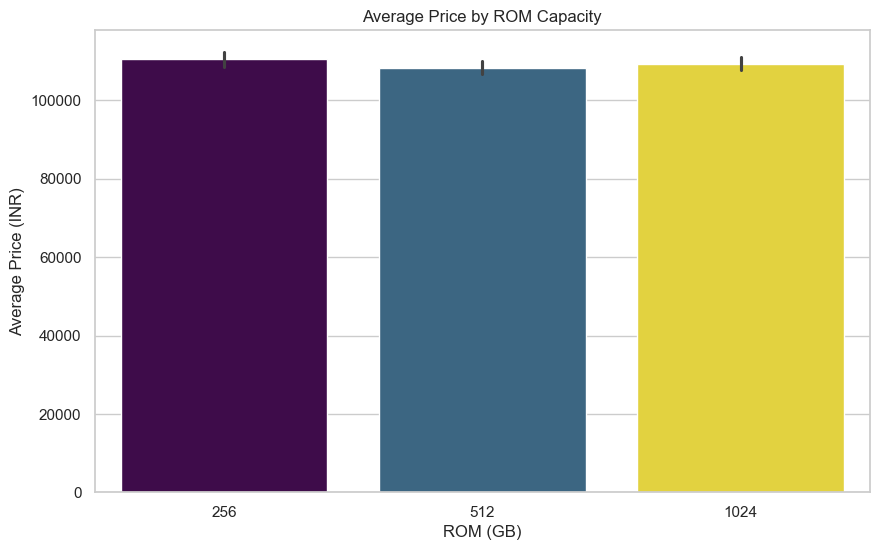

In [138]:
sns.barplot(data=df, x='Rom', y='Price', hue='Rom', palette='viridis', legend=False)
plt.title("Average Price by ROM Capacity")
plt.xlabel("ROM (GB)")
plt.ylabel("Average Price (INR)")
plt.show()


### Observation:
Average laptop price remains fairly consistent across ROM capacities (256 GB, 512 GB, and 1024 GB), suggesting that storage size alone does not significantly influence pricing.

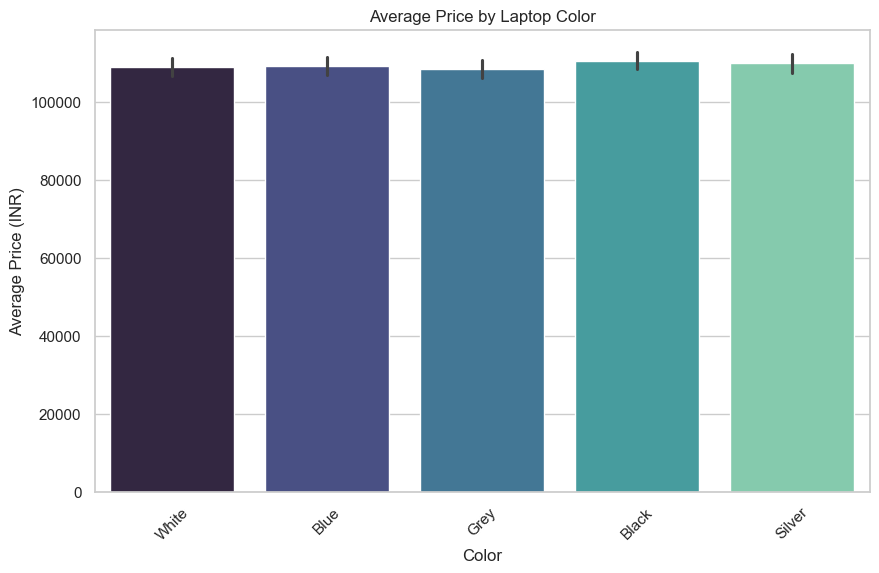

In [139]:
sns.barplot(data=df, x='Color', y='Price', hue='Color', palette='mako', legend=False)
plt.title("Average Price by Laptop Color")
plt.xlabel("Color")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)
plt.show()


### Observation:
Laptop color has minimal impact on average price. Silver and white models show slightly higher pricing, but overall, prices remain consistent across all colors.

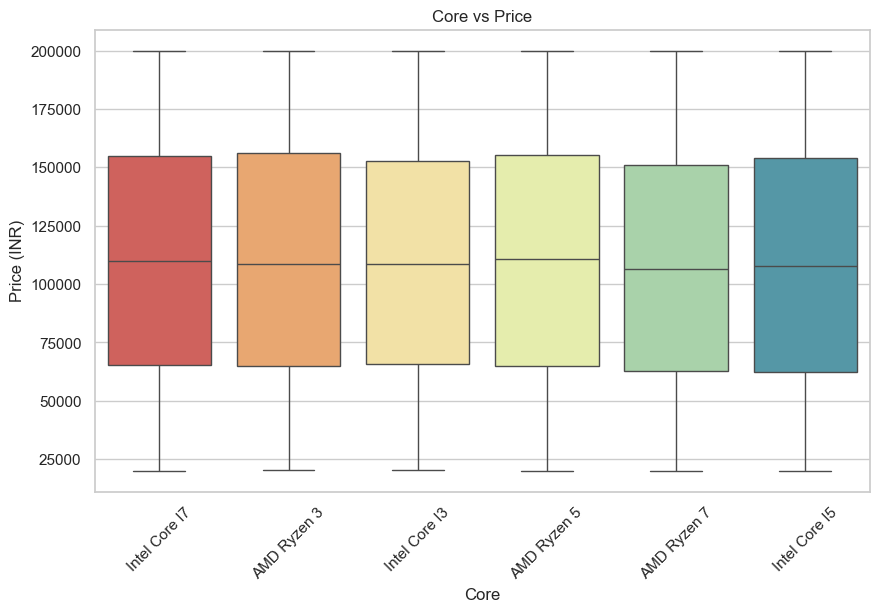

In [133]:
sns.boxplot(data=df, x='Core', y='Price', palette='Spectral')
plt.title("Core vs Price")
plt.xlabel("Core")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)
plt.show()



### Observation:
Premium processors like Intel Core i9, i7 and AMD Ryzen 7 show higher price ranges, while entry-level cores such as Intel Core i3 and Ryzen 3 remain more affordable.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Intel Core I7'),
  Text(1, 0, 'AMD Ryzen 3'),
  Text(2, 0, 'Intel Core I3'),
  Text(3, 0, 'AMD Ryzen 5'),
  Text(4, 0, 'AMD Ryzen 7'),
  Text(5, 0, 'Intel Core I5')])

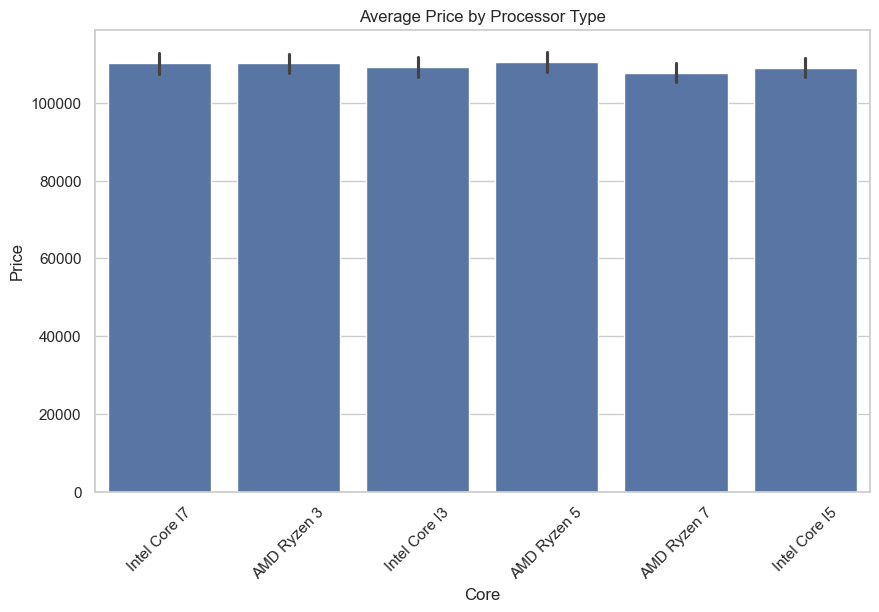

In [134]:
sns.barplot(x='Core', y='Price', data=df)
plt.title("Average Price by Processor Type")
plt.xticks(rotation=45)


### Observation:
Intel Core i7 and AMD Ryzen 7 show the highest average prices, reflecting their premium positioning. Mid-range processors like Intel Core i5 and AMD Ryzen 5 offer competitive pricing, while entry-level options such as Intel Core i3 and AMD Ryzen 3 remain the most affordable. The overall price range across cores is relatively narrow, suggesting consistent pricing strategies across brands.

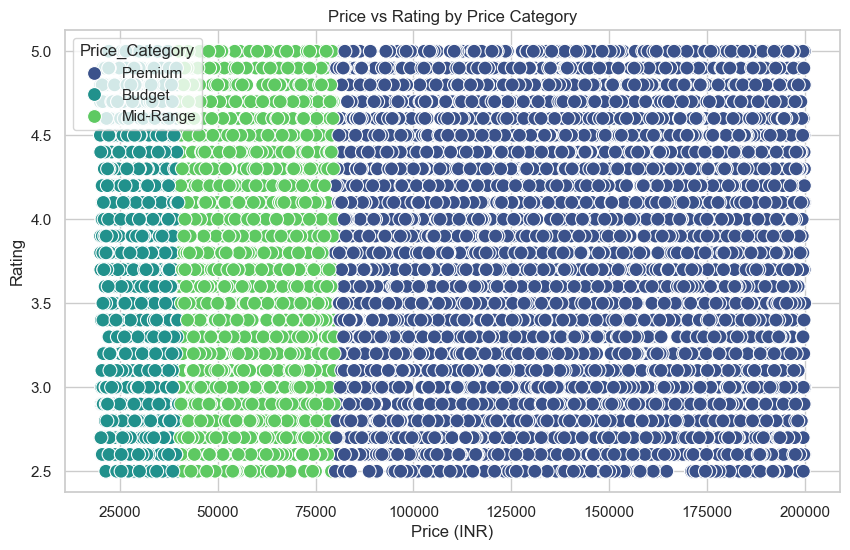

In [135]:
sns.scatterplot(data=df, x='Price', y='Rating', hue='Price_Category', palette='viridis', s=100)
plt.title("Price vs Rating by Price Category")
plt.xlabel("Price (INR)")
plt.ylabel("Rating")
plt.show()


### Observation: 
Budget products cluster at lower price points and maintain solid ratings, indicating good value for money. Premium items appear at higher prices but show varied ratings, suggesting that higher cost doesn't always guarantee better user satisfaction. Mid-range products are spread across both price and rating, reflecting a balance between affordability and performance.

## Multivariate Analysis

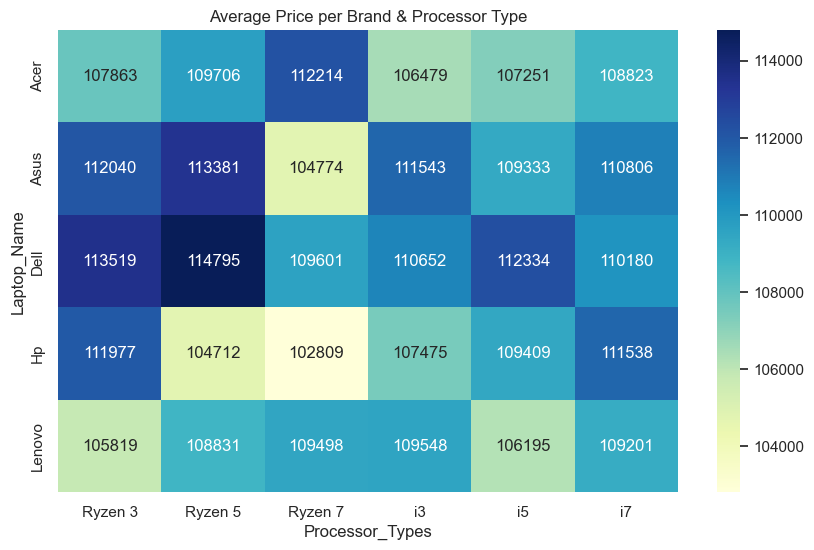

In [111]:
pivot = df.pivot_table(index='Laptop_Name', columns='Processor_Types', values='Price', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Average Price per Brand & Processor Type")
plt.show()

### Observation:
Average laptop prices vary across brand–processor combinations. Dell and Asus show higher pricing for Ryzen 5 and i5 processors, while HP and Lenovo maintain more consistent pricing across all cores. Acer offers competitive rates for Ryzen 7 and i3 models, suggesting a value-focused strategy. Overall, Ryzen 5 and Intel i5 configurations tend to be priced higher across most brands.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Asus'),
  Text(1, 0, 'Acer'),
  Text(2, 0, 'Lenovo'),
  Text(3, 0, 'Hp'),
  Text(4, 0, 'Dell')])

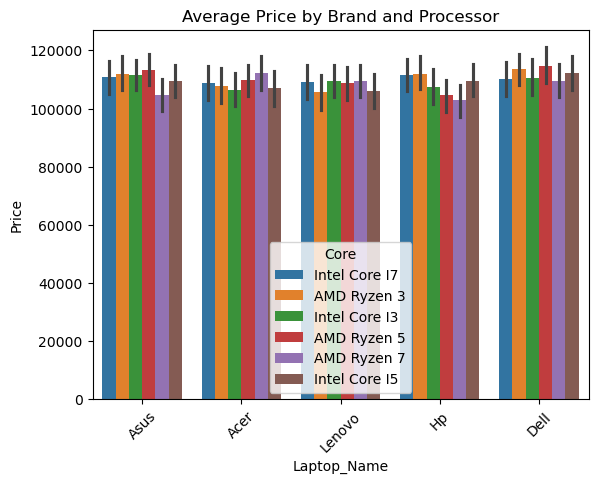

In [98]:
sns.barplot(x='Laptop_Name', y='Price', hue='Core', data=df)
plt.title("Average Price by Brand and Processor")
plt.xticks(rotation=45)


### Observation:
Laptops with Intel Core i7 and AMD Ryzen 7 processors are generally priced higher across all brands, while Intel Core i3 and AMD Ryzen 3 models remain the most affordable.

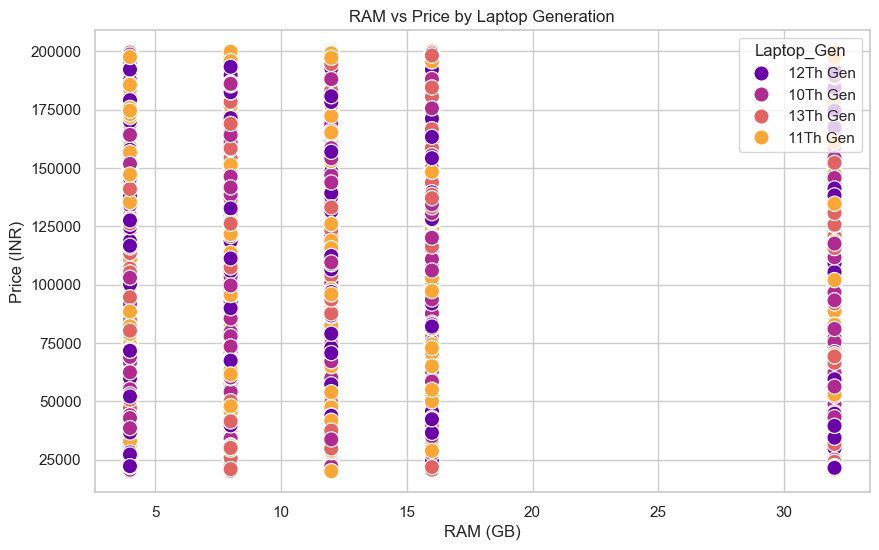

In [112]:
sns.scatterplot(data=df, x='Ram', y='Price', hue='Laptop_Gen', palette='plasma', s=120)
plt.title("RAM vs Price by Laptop Generation")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.show() 

### Observation:
Higher RAM configurations generally correspond to higher prices. Newer generations like 12th and 13th Gen tend to dominate the upper price range, while older generations cluster around lower RAM and price points, reflecting performance-based pricing.

Text(0.5, 1.0, 'Price by Generation and RAM')

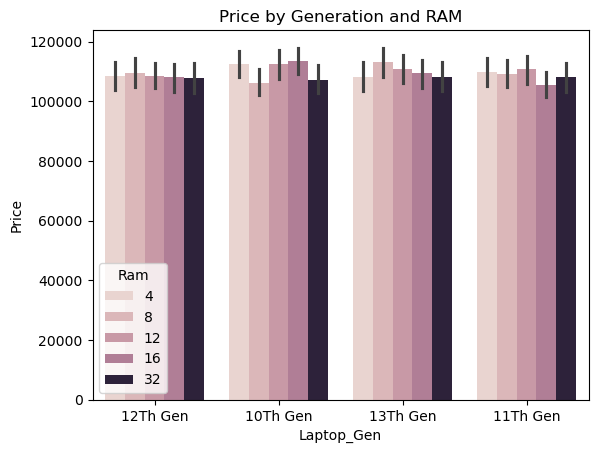

In [100]:
sns.barplot(x='Laptop_Gen', y='Price', hue='Ram', data=df)
plt.title("Price by Generation and RAM")


### Observation:
Laptops with higher RAM tend to be priced higher across all generations, with 12th and 13th Gen models showing the highest price range.

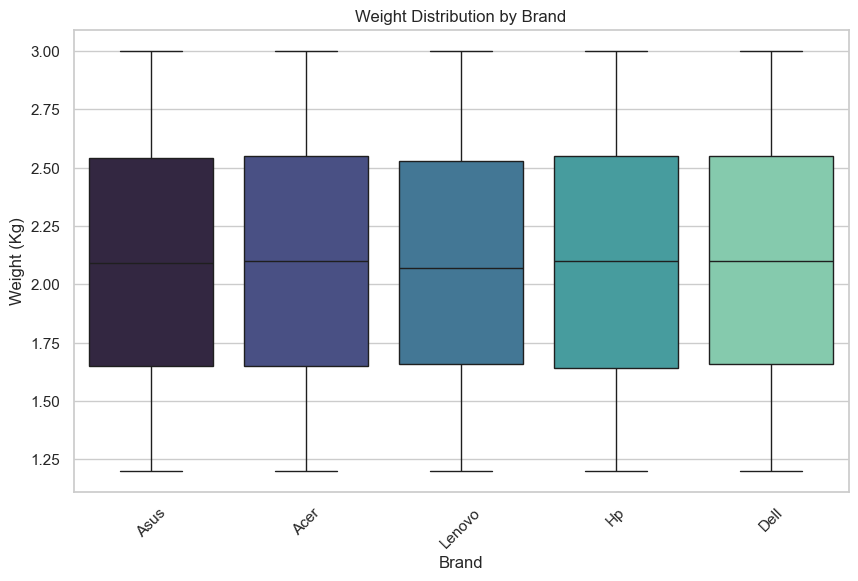

In [119]:
sns.boxplot(data=df, x='Laptop_Name', y='Weight_In_Kg', palette='mako')
plt.title("Weight Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Weight (Kg)")
plt.xticks(rotation=45)
plt.show()


### Observation:
Laptop weights vary across brands, with most models falling between 1.5 kg and 2.5 kg. Lenovo and HP show slightly lighter distributions, while Dell and Acer include heavier options.

<Axes: >

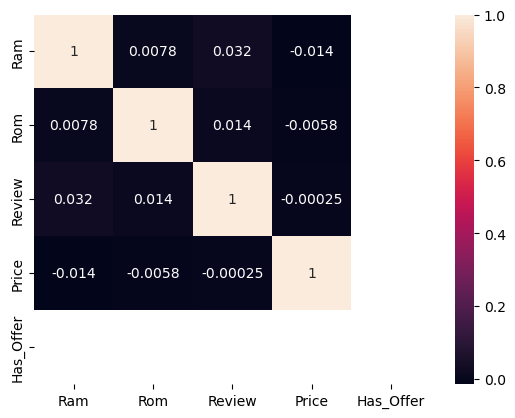

In [101]:
colm=df.select_dtypes(int,float)
a=colm.corr()
sns.heatmap(a,annot=True)

### Observation:
There is no strong correlation between price and other variables like RAM, ROM, or review score, indicating that pricing is influenced by multiple independent factors

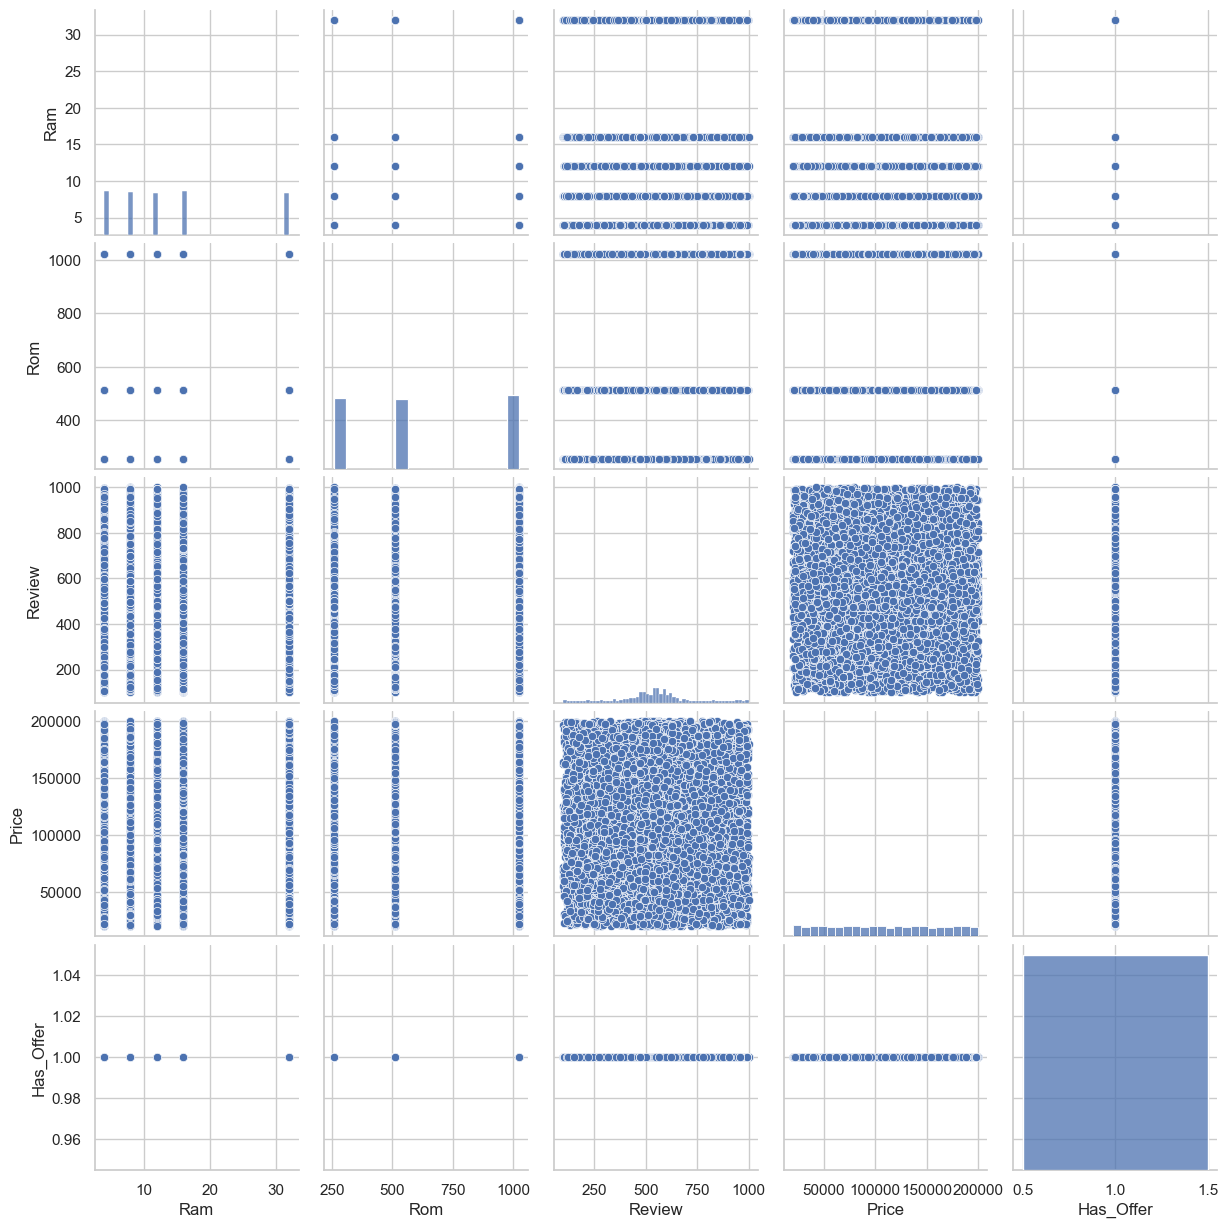

In [120]:
sns.pairplot(df.select_dtypes(int,float))

### Observation:
The variables show weak relationships with each other, and most distributions are skewed or uneven. Price and review appear largely independent, while RAM and ROM show minimal correlation.

### 🏁 Final Conclusion & Key Insights
After exploring the laptop dataset through detailed visual analysis, here are the key takeaways:

## 🔹 Brand & Pricing
Dell and Asus tend to be more expensive.

Lenovo and Acer offer better value for budget buyers.

## 🔹 Processor Impact
Core i9, i7 and Ryzen 7 are priced highest.

Core i5 and Ryzen 5 hit the sweet spot for mid-range value.

Core i3 and Ryzen 3 are the most affordable options.

## 🔹 RAM & Generation
More RAM means higher price — especially at 16 GB and above.

Newer generations (12th & 13th Gen) cost more, even with similar specs.

Mid-range setups (8–16 GB RAM, 10th–11th Gen) offer the best balance.

## 🔹 Ratings vs Price
Expensive laptops don’t always get better ratings.

Users prefer well-balanced specs over just high price tags.

## 🔹 Brand–Processor Mix
Dell and Asus price mid-range processors higher.

HP and Lenovo keep pricing more consistent across cores.

## 🔹 Weight & Design
Most laptops weigh between 1.5–2.8 kg.

Lighter models are common in budget and mid-range categories.

## 🔹 Other Factors
ROM size and laptop color don’t strongly affect price.

RAM has a mild correlation with price; other features show weak links.

### 🧩 Summary:
## Mid-range laptops with i5/Ryzen 5, 8–16 GB RAM, and 10th–11th Gen processors offer the best mix of price, performance, and user satisfaction. Premium models target power users, while entry-level ones suit basic needs. This EDA shows how visual analysis can uncover real business insights — perfect for analyst roles and portfolio projects.